In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
df = pd.read_csv('FinMark_Week3_Final.csv')
df.head()

,Customer_ID,Satisfaction_Score,Feedback_Comments,Likelihood_to_Recommend,Transaction_ID,Transaction_Date,Transaction_Amount,Transaction_Type,FirstTransactionDate,AccountAgeDays,TotalTransactionAmount,TransactionCount
0,1,10.0,Very satisfied,9,29.0,2023-01-02 04:00:00,156.0,Loan Payment,2023-01-02 04:00:00,1120,33672.0,12
1,1,10.0,Very satisfied,9,282.0,2023-01-12 17:00:00,1572.0,Bill Payment,2023-01-02 04:00:00,1120,33672.0,12
2,1,10.0,Very satisfied,9,2883.0,2023-05-01 02:00:00,4867.0,Bill Payment,2023-01-02 04:00:00,1120,33672.0,12
3,1,10.0,Very satisfied,9,3135.0,2023-05-11 14:00:00,1278.0,Investment,2023-01-02 04:00:00,1120,33672.0,12
4,1,10.0,Very satisfied,9,3626.0,2023-06-01 01:00:00,3970.0,Purchase,2023-01-02 04:00:00,1120,33672.0,12


In [3]:
df['Transaction_Date'] = df['Transaction_Date'].fillna(pd.Timestamp('1970-01-01'))
df['FirstTransactionDate'] = df['FirstTransactionDate'].fillna(pd.Timestamp('1970-01-01'))

df['AccountAgeDays'] = (pd.Timestamp('2026-01-27') - pd.to_datetime(df['FirstTransactionDate'])).dt.days

df['Transaction_Type'] = df['Transaction_Type'].str.title().str.strip()


In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['Transaction_Amount', 'AccountAgeDays']] = scaler.fit_transform(
    df[['Transaction_Amount', 'AccountAgeDays']]
)


In [5]:
df[['Transaction_Amount', 'AccountAgeDays']].head()


,Transaction_Amount,AccountAgeDays
0,0.000325,0.010478
1,0.003273,0.010478
2,0.010133,0.010478
3,0.002661,0.010478
4,0.008266,0.010478


In [7]:
# Avg Transaction Amount per customer
df['Avg_Transaction_Amount'] = df.groupby('Customer_ID')['Transaction_Amount'].transform('mean')

# Transaction Frequency
df['Transaction_Frequency'] = df.groupby('Customer_ID')['Transaction_ID'].transform('count') / df['AccountAgeDays']

# One-hot encoding for Transaction_Type
df_fe = pd.get_dummies(df, columns=['Transaction_Type'])

# Show feature-engineered columns
df_fe[['Customer_ID',
       'Avg_Transaction_Amount',
       'Transaction_Frequency',
       'Transaction_Type_Purchase',
       'Transaction_Type_Loan Payment',
       'Transaction_Type_No Transaction']].head()


,Customer_ID,Avg_Transaction_Amount,Transaction_Frequency,Transaction_Type_Purchase,Transaction_Type_Loan Payment,Transaction_Type_No Transaction
0,1,0.005842,1145.268293,False,True,False
1,1,0.005842,1145.268293,False,False,False
2,1,0.005842,1145.268293,False,False,False
3,1,0.005842,1145.268293,False,False,False
4,1,0.005842,1145.268293,True,False,False


In [21]:
numerical_features = [
    'Transaction_Amount',
    'AccountAgeDays',
    'Avg_Transaction_Amount',
    'Transaction_Frequency',
    'Satisfaction_Score',
    'Likelihood_to_Recommend'
]

df[numerical_features].describe()

,Transaction_Amount,AccountAgeDays,Avg_Transaction_Amount,Transaction_Frequency,Satisfaction_Score,Likelihood_to_Recommend
count,25000.000000,25000.000000,25000.000000,2.500000e+04,25000.000000,25000.000000
mean,0.006430,0.010215,0.006430,inf,5.690313,5.526560
std,0.030660,0.036564,0.013026,NaN,3.567779,2.872188
min,0.000000,0.000000,0.000000,3.000000e+00,1.000000,1.000000
25%,0.002598,0.008178,0.004253,2.395714e+03,3.000000,3.000000
50%,0.005170,0.009353,0.005122,3.600920e+03,6.000000,6.000000
75%,0.007618,0.010069,0.005984,5.204483e+03,8.000000,8.000000
max,1.000000,1.000000,0.300112,inf,60.000000,10.000000


In [32]:
df_viz = df.copy()
df_viz.replace([np.inf, -np.inf], np.nan, inplace=True)

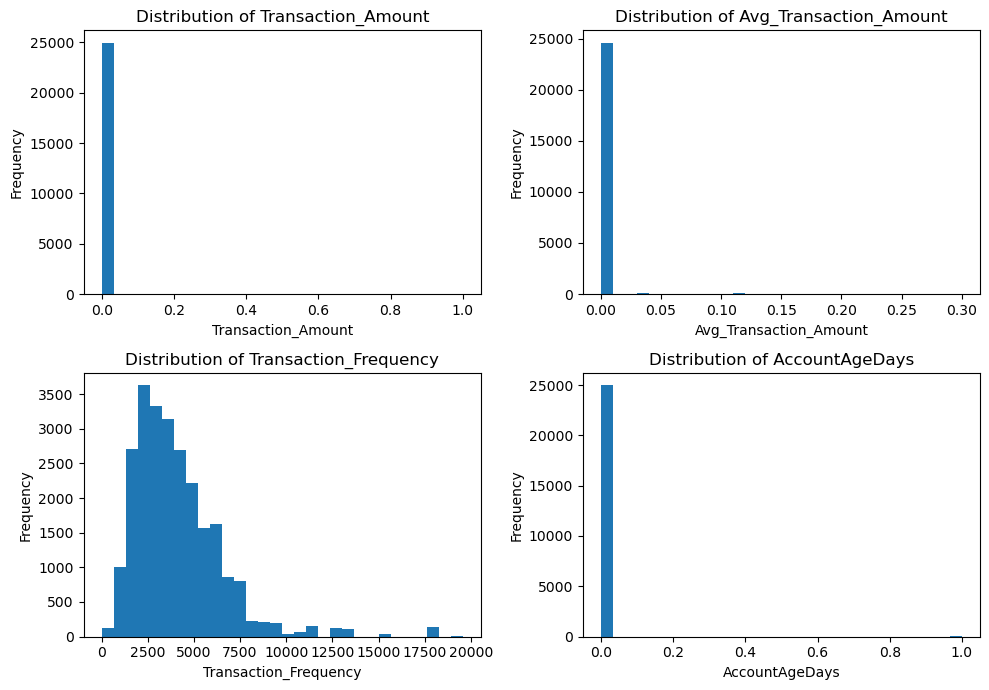

In [37]:
plt.figure(figsize=(10, 7))

for i, col in enumerate(
    ['Transaction_Amount', 'Avg_Transaction_Amount',
     'Transaction_Frequency', 'AccountAgeDays'], 1):

    plt.subplot(2, 2, i)
    plt.hist(df_viz[col].dropna(), bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

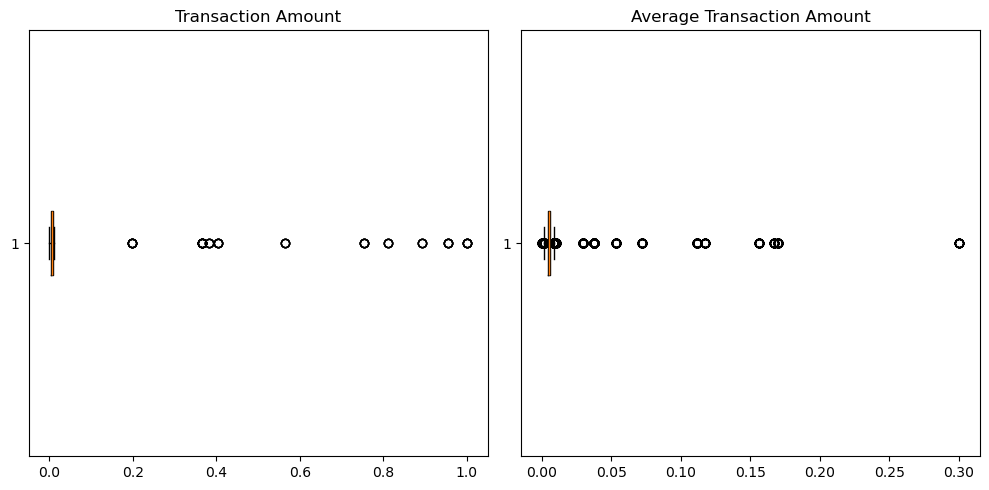

In [38]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.boxplot(df_viz['Transaction_Amount'].dropna(), vert=False)
plt.title('Transaction Amount')

plt.subplot(1, 2, 2)
plt.boxplot(df_viz['Avg_Transaction_Amount'].dropna(), vert=False)
plt.title('Average Transaction Amount')

plt.tight_layout()
plt.show()

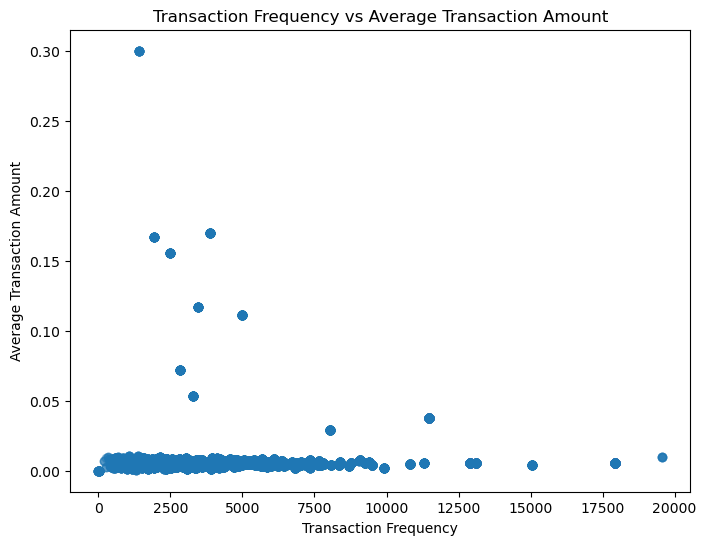

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_viz['Transaction_Frequency'],
    df_viz['Avg_Transaction_Amount'],
    alpha=0.5
)

plt.xlabel('Transaction Frequency')
plt.ylabel('Average Transaction Amount')
plt.title('Transaction Frequency vs Average Transaction Amount')

plt.show()

In [40]:
numerical_features = [
    'Transaction_Amount',
    'Avg_Transaction_Amount',
    'Transaction_Frequency',
    'AccountAgeDays'
]

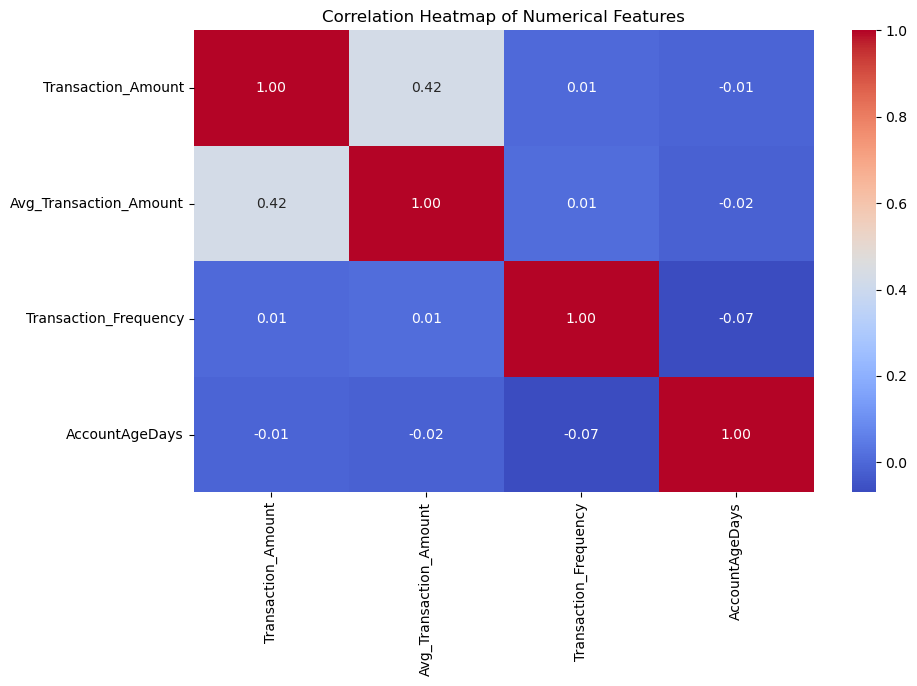

In [41]:
plt.figure(figsize=(10, 6))

corr = df_viz[numerical_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [43]:
df.to_csv("FinMark_WEEK3Final.csv", index=False)
